In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_excel("marketing_campaign.xlsx")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

In [5]:
df.shape

(2240, 29)

In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [7]:
df=df.dropna() #dropped missing values because we have only 24 missing values in this income col

In [8]:
df.shape

(2216, 29)

In [9]:
df.isnull().sum().sum() #zero null values

np.int64(0)

In [10]:
df.duplicated().sum()
# we dont have duplicates in our data

np.int64(0)

In [11]:
df.nunique()

ID                     2216
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1974
Kidhome                   3
Teenhome                  3
Dt_Customer             662
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         554
MntFishProducts         182
MntSweetProducts        176
MntGoldProds            212
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
dtype: int64

In [12]:
df.Education.value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [13]:
df.Marital_Status.value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

This Absurd and Yolo these are clear noise

"YOLO" and "Absurd" aren't legal marital statuses

Some one might have enetred wrongly So this information is false and iam thinking to drop these who entred wrong data

In [14]:
df = df.drop(df[df['Marital_Status'].isin(['Absurd', 'YOLO'])].index)

df['Marital_Status'] = df['Marital_Status'].replace({'Married':'Partner','Together':'Partner',
    'Single':'Alone','Divorced':'Alone','Widow':'Alone'})

# Checking new counts
print(df['Marital_Status'].value_counts())


Marital_Status
Partner    1430
Alone       782
Name: count, dtype: int64


In [15]:
df.shape

(2212, 29)

In [16]:
df.var(numeric_only=True)

ID                     1.054914e+07
Year_Birth             1.435699e+02
Income                 6.344079e+08
Kidhome                2.884253e-01
Teenhome               2.962166e-01
Recency                8.375696e+02
MntWines               1.139814e+05
MntFruits              1.582591e+03
MntMeatProducts        5.033066e+04
MntFishProducts        2.976649e+03
MntSweetProducts       1.688590e+03
MntGoldProds           2.664983e+03
NumDealsPurchases      3.699893e+00
NumWebPurchases        7.518179e+00
NumCatalogPurchases    8.551985e+00
NumStorePurchases      1.058602e+01
NumWebVisitsMonth      5.873084e+00
AcceptedCmp3           6.828978e-02
AcceptedCmp4           6.867520e-02
AcceptedCmp5           6.751770e-02
AcceptedCmp1           5.970701e-02
AcceptedCmp2           1.338450e-02
Complain               9.407794e-03
Z_CostContact          0.000000e+00
Z_Revenue              0.000000e+00
Response               1.273043e-01
dtype: float64

Complain 2 Z_CostContact 1 Z_Revenue 1

Fomr the variance we can check this cols have variance zero for this Z_CostContact and variance is almost at zero for Z_Revenue

we dont need them so dropping this wont help in clustering

In [17]:
df.Z_Revenue.value_counts()

Z_Revenue
11    2212
Name: count, dtype: int64

In [18]:
df.Z_CostContact.value_counts()

Z_CostContact
3    2212
Name: count, dtype: int64

In [19]:
df.drop(columns=['Z_CostContact','Z_Revenue'],inplace=True)

Complain
0    2191
1      21
Name: count, dtype: int64


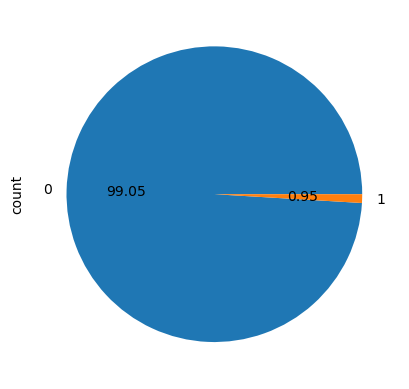

In [20]:
df.Complain.value_counts().plot(kind='pie',autopct='%.2f')
print(df.Complain.value_counts())

<Axes: xlabel='Marital_Status', ylabel='count'>

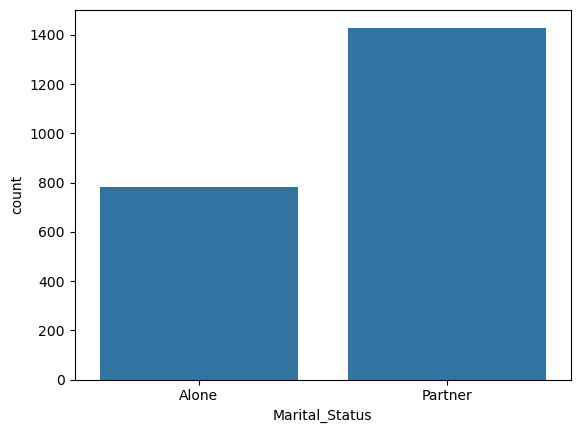

In [21]:
sns.countplot(x=df['Marital_Status'])

Feature Engineering


●	MntWines: Amount spent on wine in last 2 years

●	MntFruits: Amount spent on fruits in last 2 years

●	MntMeatProducts: Amount spent on meat in last 2 years

●	MntFishProducts: Amount spent on fish in last 2 years

●	MntSweetProducts: Amount spent on sweets in last 2 years

●	MntGoldProds: Amount spent on gold in last 2 years

so we have to sum them up to get the total sales of a person made

In [22]:
columns_to_sum = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts','MntSweetProducts','MntGoldProds']

df['TotalSpent'] = df[columns_to_sum].sum(axis=1)

● AcceptedCmp1: 1 if customer accepted the offer in the 1st campaign, 0 otherwise

● AcceptedCmp2: 1 if customer accepted the offer in the 2nd campaign, 0 otherwise

● AcceptedCmp3: 1 if customer accepted the offer in the 3rd campaign, 0 otherwise

● AcceptedCmp4: 1 if customer accepted the offer in the 4th campaign, 0 otherwise

● AcceptedCmp5: 1 if customer accepted the offer in the 5th campaign, 0 otherwise

● Response: 1 if customer accepted the offer in the last campaign, 0 otherwise

From this we can get to know this how many offers he accepted by summing them up

In [23]:
columns_to_sum1 = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4','AcceptedCmp5','Response']

df['TotalAcceptedOffers']=df[columns_to_sum1].sum(axis=1)

● NumWebPurchases: Number of purchases made through the company’s website

● NumCatalogPurchases: Number of purchases made using a catalogue

● NumStorePurchases: Number of purchases made directly in stores

By summing these we can get noof purchases each person made

In [24]:
columns_to_sum2 = ['NumWebPurchases','NumCatalogPurchases', 'NumStorePurchases']

df['TotalPurchases'] = df[columns_to_sum2].sum(axis=1)

● Kidhome: Number of children in customer's household

● Teenhome: Number of teenagers in customer's household

we can add these two cols to get TotalChildern

In [25]:
columns_to_sum3 = ['Kidhome', 'Teenhome']

df['TotalChildren'] = df[columns_to_sum3].sum(axis=1)

<Axes: xlabel='TotalChildren', ylabel='count'>

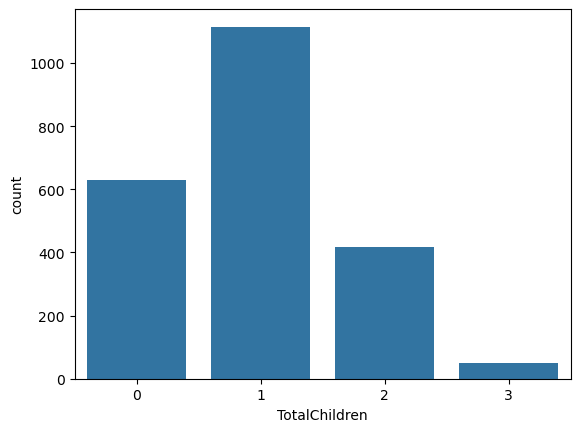

In [26]:
sns.countplot(x=df['TotalChildren'])

In [27]:
df['Age'] = 2014 - df['Year_Birth'] # calculating age of a person we took 2014 because our data is only collected till 2014 only

In [28]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

reference_date = pd.Timestamp("31-12-2014") #Here we didnt got any kind of refrance from the dataset discription so iam taking this tenure refrance date as "31-12-2014"

df['Customer_Tenure'] = (reference_date - df['Dt_Customer']).dt.days

Checking cols for extreme outliers

<Axes: xlabel='Recency'>

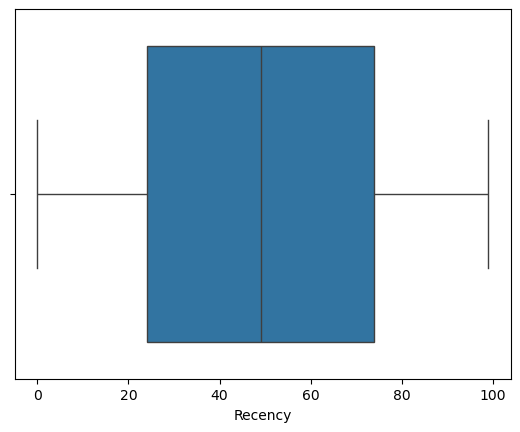

In [29]:
sns.boxplot(x=df["Recency"],data=df)

<Axes: xlabel='Income'>

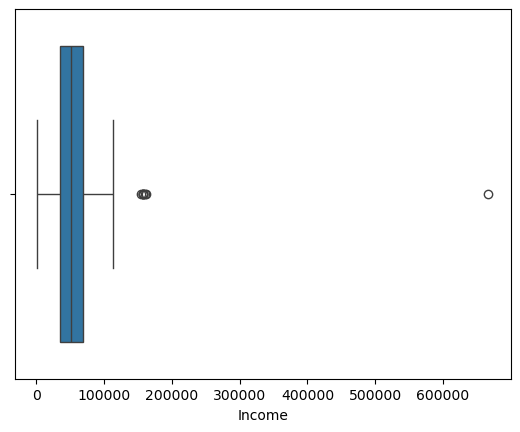

In [30]:
sns.boxplot(x=df["Income"]) # we have to remove this outlier of income > 6000000
#This outlier is way more far so we need to remove this

In [31]:
df.Income.describe()

count      2212.000000
mean      52232.510850
std       25187.455359
min        1730.000000
25%       35233.500000
50%       51381.500000
75%       68522.000000
max      666666.000000
Name: Income, dtype: float64

In [32]:
df[df['Income']>130000]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Complain,Response,TotalSpent,TotalAcceptedOffers,TotalPurchases,TotalChildren,Age,Customer_Tenure
164,8475,1973,PhD,Partner,157243.0,0,1,2014-03-01,98,20,...,0,0,0,0,1608,0,22,1,41,305
617,1503,1976,PhD,Partner,162397.0,1,1,2013-06-03,31,85,...,0,0,0,0,107,0,1,2,38,576
655,5555,1975,Graduation,Alone,153924.0,0,0,2014-02-07,81,1,...,0,0,0,0,6,0,0,0,39,327
687,1501,1982,PhD,Partner,160803.0,0,0,2012-08-04,21,55,...,0,0,0,0,1717,0,29,0,32,879
1300,5336,1971,Master,Partner,157733.0,1,0,2013-06-04,37,39,...,0,0,0,0,59,0,2,1,43,575
1653,4931,1977,Graduation,Partner,157146.0,0,0,2013-04-29,13,1,...,0,0,0,0,1730,0,28,0,37,611
2132,11181,1949,PhD,Partner,156924.0,0,0,2013-08-29,85,2,...,0,0,0,0,8,0,0,0,65,489
2233,9432,1977,Graduation,Partner,666666.0,1,0,2013-06-02,23,9,...,0,0,0,0,62,0,7,1,37,577


In [33]:
#df[df['Income']>300000]

In [34]:
df=df[df['Income']<300000]

<Axes: xlabel='Income'>

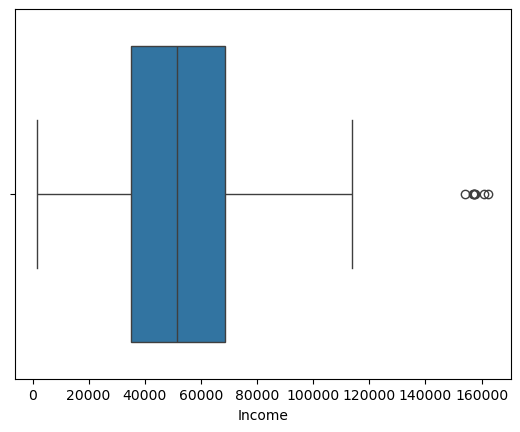

In [35]:
sns.boxplot(x=df['Income'])

['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts','MntSweetProducts','MntGoldProds'] this all cols are summed up to this TotlaSpent so checking oultiers only for this Total Spent

<Axes: xlabel='TotalSpent'>

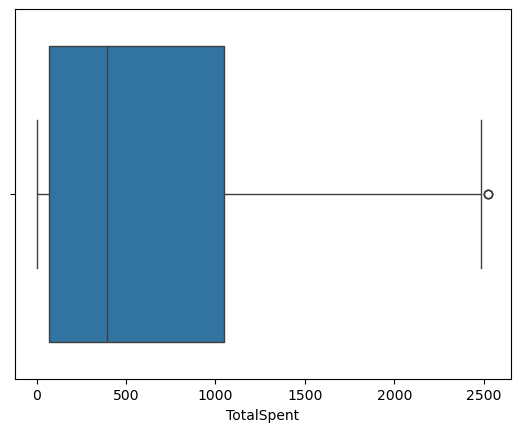

In [36]:
sns.boxplot(x=df["TotalSpent"],data=df)

<Axes: xlabel='TotalPurchases'>

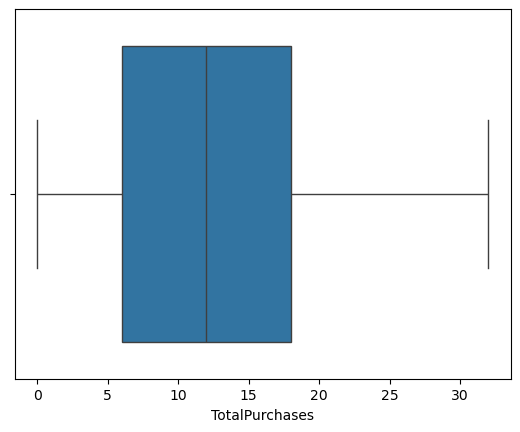

In [37]:
sns.boxplot(x=df["TotalPurchases"],data=df)

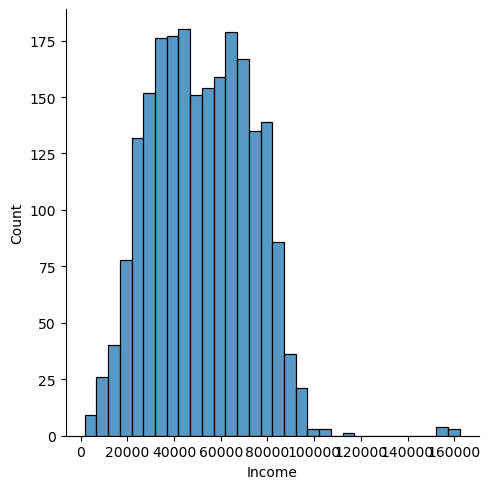

In [38]:
sns.displot(x=df['Income'])

In [39]:
df.Income.skew()

np.float64(0.34861821856877945)

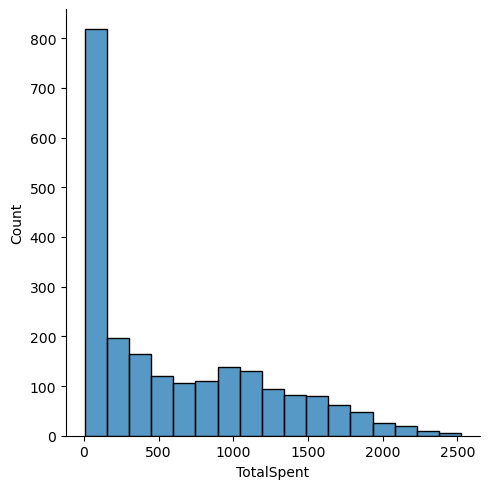

In [40]:
sns.displot(df['TotalSpent'])

In [41]:
df.TotalSpent.skew()

np.float64(0.858880039583507)

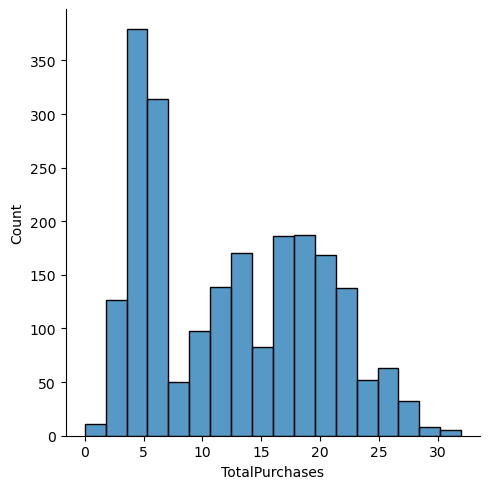

In [42]:
sns.displot(df['TotalPurchases'])

In [43]:
df.TotalPurchases.skew()

np.float64(0.295053464962466)

Encoding

In [44]:
from sklearn.preprocessing import OrdinalEncoder
education_order = [['Basic', '2n Cycle', 'Graduation', 'Master', 'PhD']]
encoder = OrdinalEncoder(categories=education_order)

df['Education_Encoded'] = encoder.fit_transform(df[['Education']])

In [45]:
df['Education_Encoded']

0       2.0
1       2.0
2       2.0
3       2.0
4       4.0
       ... 
2235    2.0
2236    4.0
2237    2.0
2238    3.0
2239    4.0
Name: Education_Encoded, Length: 2211, dtype: float64

One hot encoding

In [46]:
df = pd.get_dummies(df, columns=['Marital_Status'], drop_first=True)
#1 means Customer has partner
#0 means Customer is alone

<Axes: xlabel='Income', ylabel='TotalSpent'>

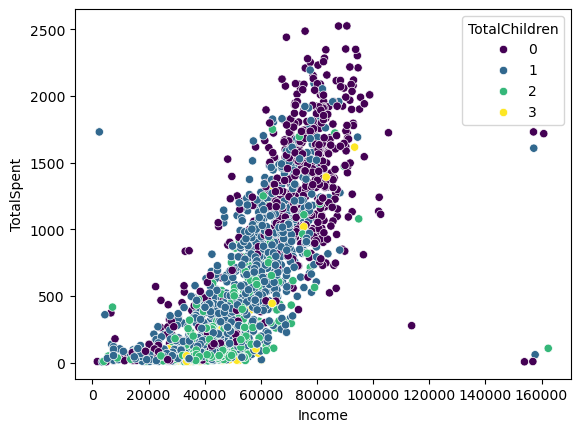

In [47]:
sns.scatterplot(x=df['Income'],y=df['TotalSpent'],hue=df['TotalChildren'],palette='viridis')

<Axes: xlabel='Income', ylabel='TotalSpent'>

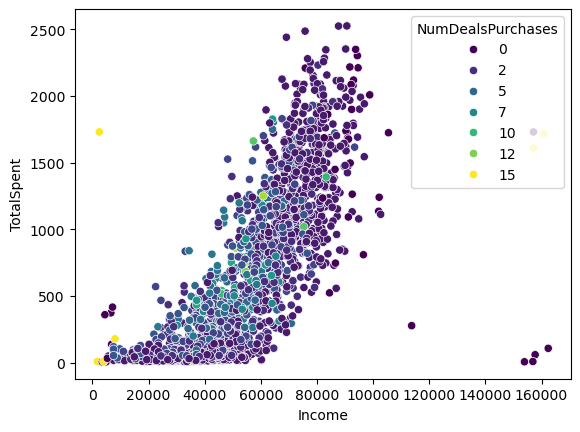

In [48]:
sns.scatterplot(x=df['Income'],y=df['TotalSpent'],hue=df['NumDealsPurchases'],palette='viridis')

<Axes: xlabel='Income', ylabel='TotalSpent'>

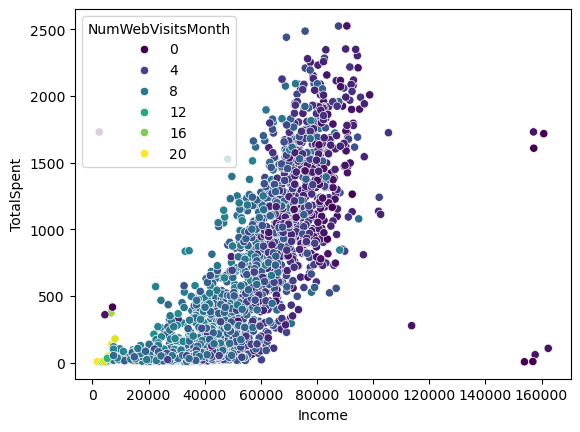

In [49]:
sns.scatterplot(x=df['Income'],y=df['TotalSpent'],hue=df['NumWebVisitsMonth'],palette='viridis')

<Axes: xlabel='Income', ylabel='TotalSpent'>

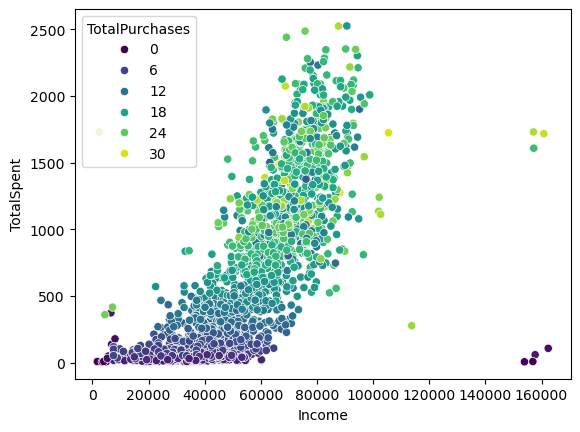

In [50]:
sns.scatterplot(x=df['Income'],y=df['TotalSpent'],hue=df['TotalPurchases'],palette='viridis')

<Axes: xlabel='Income', ylabel='TotalSpent'>

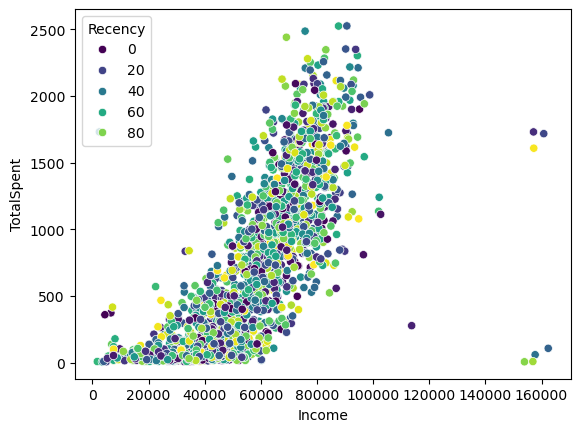

In [51]:
sns.scatterplot(x=df['Income'],y=df['TotalSpent'],hue=df['Recency'],palette='viridis')

<Axes: xlabel='Income', ylabel='TotalSpent'>

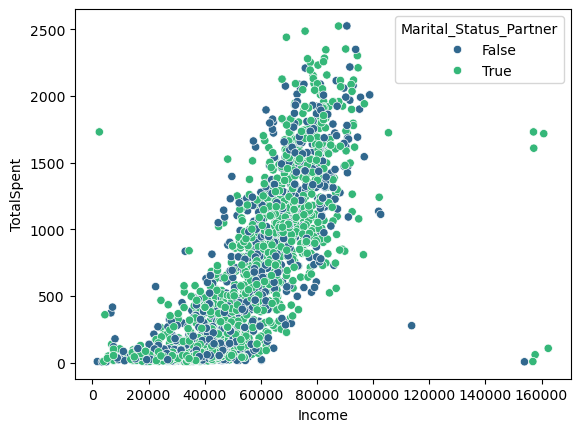

In [52]:
sns.scatterplot(x=df['Income'],y=df['TotalSpent'],hue=df['Marital_Status_Partner'],palette='viridis')


<Axes: xlabel='Income', ylabel='TotalSpent'>

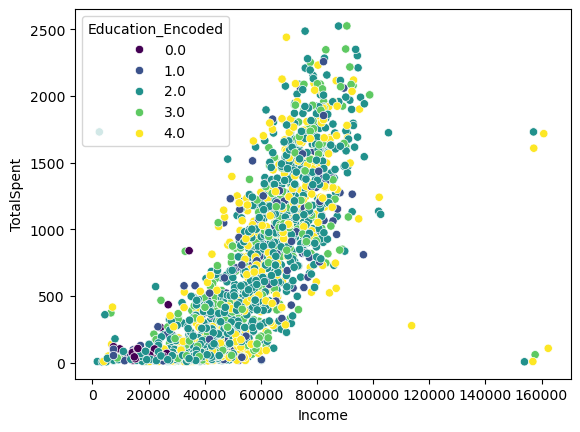

In [53]:
sns.scatterplot(x=df['Income'],y=df['TotalSpent'],hue=df['Education_Encoded'],palette='viridis')

In [54]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Income', 'Kidhome', 'Teenhome',
       'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
       'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
       'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
       'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3',
       'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2',
       'Complain', 'Response', 'TotalSpent', 'TotalAcceptedOffers',
       'TotalPurchases', 'TotalChildren', 'Age', 'Customer_Tenure',
       'Education_Encoded', 'Marital_Status_Partner'],
      dtype='object')

In [55]:
df=df[['Age','Income','TotalChildren','Customer_Tenure','TotalSpent','NumDealsPurchases','TotalPurchases','NumWebVisitsMonth','TotalAcceptedOffers','Education_Encoded','Marital_Status_Partner','Recency']]

#from 29 features to 13 features

#k=4 score= 0.4324

In [56]:
df.corr()

,Age,Income,TotalChildren,Customer_Tenure,TotalSpent,NumDealsPurchases,TotalPurchases,NumWebVisitsMonth,TotalAcceptedOffers,Education_Encoded,Marital_Status_Partner,Recency
Age,1.000000,0.199218,0.087029,-0.018559,0.113840,0.058739,0.166496,-0.124858,-0.005071,0.184962,-0.002869,0.015856
Income,0.199218,1.000000,-0.343350,-0.024291,0.792501,-0.108117,0.741871,-0.650395,0.342723,0.181219,-0.003155,0.006553
TotalChildren,0.087029,-0.343350,1.000000,-0.026023,-0.499776,0.436602,-0.382288,0.415210,-0.253642,0.061145,0.040817,0.018614
Customer_Tenure,-0.018559,-0.024291,-0.026023,1.000000,0.159232,0.217748,0.163454,0.275733,0.068245,-0.062686,-0.009283,0.027840
TotalSpent,0.113840,0.792501,-0.499776,0.159232,1.000000,-0.065071,0.822995,-0.498453,0.453631,0.110085,-0.018276,0.019175
NumDealsPurchases,0.058739,-0.108117,0.436602,0.217748,-0.065071,1.000000,0.117337,0.345211,-0.093520,0.031101,0.027429,0.004582
TotalPurchases,0.166496,0.741871,-0.382288,0.163454,0.822995,0.117337,1.000000,-0.426611,0.298168,0.114392,0.000691,0.007268
NumWebVisitsMonth,-0.124858,-0.650395,0.415210,0.275733,-0.498453,0.345211,-0.426611,1.000000,-0.125326,-0.057641,0.002364,-0.016687
TotalAcceptedOffers,-0.005071,0.342723,-0.253642,0.068245,0.453631,-0.093520,0.298168,-0.125326,1.000000,0.072724,-0.058211,-0.091235
Education_Encoded,0.184962,0.181219,0.061145,-0.062686,0.110085,0.031101,0.114392,-0.057641,0.072724,1.000000,-0.006933,-0.011799


In [57]:
#df=df[['Income','TotalSpent','TotalChildren','NumDealsPurchases','NumWebVisitsMonth']]
#k=4 score = 0.4599

#df=df[['TotalSpent','TotalChildren','NumDealsPurchases','NumWebVisitsMonth']]
#removed income for features k=4 score = 0.4204

#df=df[['Income','TotalChildren','NumDealsPurchases','NumWebVisitsMonth']]
#now Total spent removed  k=4 score = 0.4233

df=df[['Income','TotalSpent','TotalChildren','NumDealsPurchases','NumWebVisitsMonth','TotalPurchases']] #added total purchases    k=4 score = 0.4842

#df=df[['Income','TotalSpent','TotalChildren','NumDealsPurchases','NumWebVisitsMonth','TotalPurchases','Age','Customer_Tenure']] #added Age and Customer_Tenurek=4 score = 0.4842 Silhouette = 0.4396

#df=df[['Income','TotalSpent','TotalChildren','NumDealsPurchases','NumWebVisitsMonth','TotalPurchases','Customer_Tenure']] #adde Customer_Tenurek=4 score = 0.4842 Silhouette = 0.4762

#df=df[['Income','TotalSpent','TotalChildren','NumDealsPurchases','NumWebVisitsMonth','TotalPurchases','Age']] #adde Age k=4 score = 0.4842 Silhouette = 0.4531

#df=df[['Income','TotalChildren','NumDealsPurchases','NumWebVisitsMonth','TotalPurchases']]
#removed totlaspent       k=4 score  = 0.4682

#df=df[['Income','TotalSpent','TotalChildren','NumDealsPurchases','NumWebVisitsMonth','TotalPurchases','Marital_Status_Partner']] #           # k=4 score = 0.4836

#df=df[['Income','TotalSpent','TotalChildren','NumDealsPurchases','NumWebVisitsMonth','TotalPurchases','Marital_Status_Partner','TotalAcceptedOffers']]     #  k=4 score = 0.4738

#df=df[['Income','TotalSpent','TotalChildren','NumDealsPurchases','NumWebVisitsMonth','TotalPurchases','Recency']] #with recency and 'Marital_Status_Partner' k=4 score= 0.4836


#df=df[['Income','TotalSpent','TotalChildren','NumDealsPurchases','NumWebVisitsMonth','TotalPurchases','Recency','Marital_Status_Partner']]    k=4 score = 0.4827



#df=df[['Age','Income','TotalSpent','TotalPurchases','NumWebVisitsMonth','Recency']] #k=4 score= 0.3858
#k=3 score = 0.4233

#df=df[['Age','Income','TotalSpent','TotalChildren']] #amar kuttu features

In [58]:
from sklearn.preprocessing import StandardScaler
X=df
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

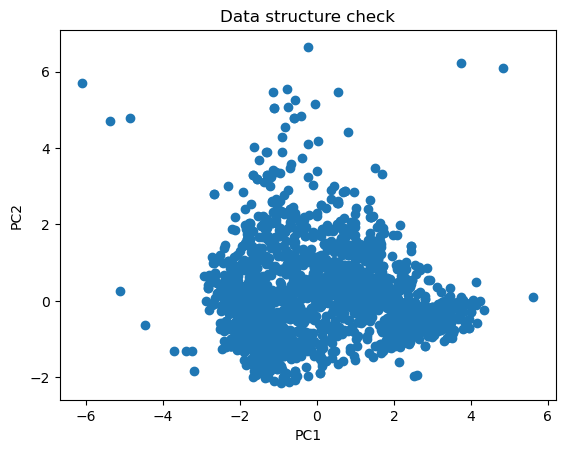

In [59]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# plot
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Data structure check")
plt.show()

In [60]:
X_pca.shape

(2211, 2)

In [61]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [62]:
wcss = []                 # for elbow method
silhouette_scores = []    # for silhouette method

K_range = range(2, 11)    # silhouette needs k >= 2

for k in K_range:

    kmeans = KMeans(n_clusters=k,init='k-means++',random_state=42,n_init=10)

    labels = kmeans.fit_predict(X_pca)

    # Elbow metric (WCSS / inertia)
    wcss.append(kmeans.inertia_)

    # Silhouette score
    sil_score = silhouette_score(X_pca, labels)
    silhouette_scores.append(sil_score)

    print(f"k = {k} | WCSS = {kmeans.inertia_:.2f} | Silhouette = {sil_score:.4f}")

k = 2 | WCSS = 4597.74 | Silhouette = 0.5095
k = 3 | WCSS = 2903.42 | Silhouette = 0.4985
k = 4 | WCSS = 2182.67 | Silhouette = 0.4842
k = 5 | WCSS = 1789.03 | Silhouette = 0.4125
k = 6 | WCSS = 1527.41 | Silhouette = 0.4143
k = 7 | WCSS = 1332.59 | Silhouette = 0.4103
k = 8 | WCSS = 1182.90 | Silhouette = 0.3790
k = 9 | WCSS = 1063.98 | Silhouette = 0.3642
k = 10 | WCSS = 957.43 | Silhouette = 0.3717


Elbow Plot

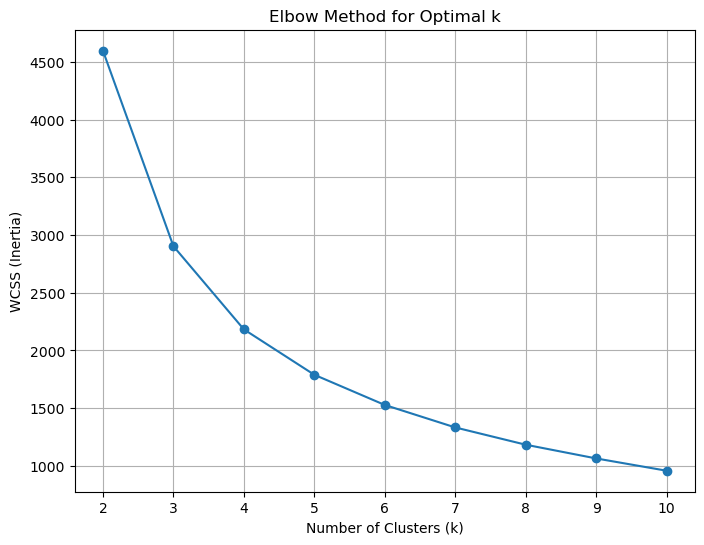

In [63]:
plt.figure(figsize=(8,6))

plt.plot(K_range, wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal k")
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [64]:
kmeans = KMeans(n_clusters=4,init='k-means++',random_state=42,n_init=10)

labels_km = kmeans.fit_predict(X_pca)

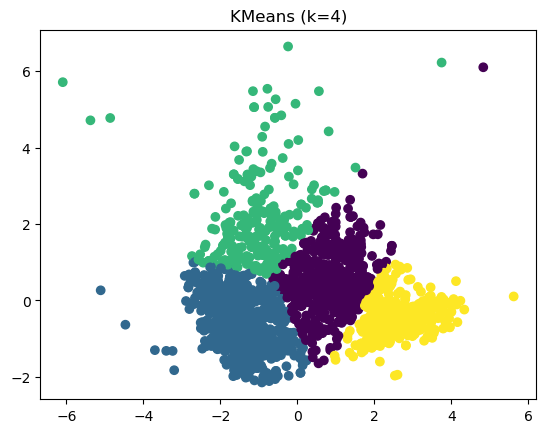

In [65]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_km, cmap='viridis')
plt.title("KMeans (k=4)")
plt.show()

In [66]:
df['Cluster'] = labels_km

In [67]:
df

,Income,TotalSpent,TotalChildren,NumDealsPurchases,NumWebVisitsMonth,TotalPurchases,Cluster
0,58138.0,1617,0,3,7,22,0
1,46344.0,27,2,2,5,4,1
2,71613.0,776,0,1,4,20,3
3,26646.0,53,1,2,6,6,1
4,58293.0,422,1,5,5,14,0
...,...,...,...,...,...,...,...
2235,61223.0,1341,1,2,5,16,0
2236,64014.0,444,3,7,7,15,2
2237,56981.0,1241,0,1,6,18,0
2238,69245.0,843,1,2,3,21,0


In [68]:
cluster_profile = df.groupby('Cluster').mean().round(2)
cluster_profile

,Income,TotalSpent,TotalChildren,NumDealsPurchases,NumWebVisitsMonth,TotalPurchases
Cluster,,,,,,
0,62605.15,871.69,0.96,2.63,5.02,18.33
1,33651.95,93.26,1.18,1.83,6.47,5.75
2,48982.03,503.60,1.71,6.19,7.19,13.79
3,78471.32,1397.75,0.08,0.97,2.39,19.29


In [69]:
df.groupby('Cluster').count()

,Income,TotalSpent,TotalChildren,NumDealsPurchases,NumWebVisitsMonth,TotalPurchases
Cluster,,,,,,
0,514,514,514,514,514,514
1,961,961,961,961,961,961
2,251,251,251,251,251,251
3,485,485,485,485,485,485


In [70]:
cluster_names = {
    0: "Frequent Buyers",
    1: "Low Spenders",
    2: "Deal Buyers",
    3: "High Spenders"
}

df['Cluster_Name'] = df['Cluster'].map(cluster_names)

In [71]:
df.groupby('Cluster_Name').mean()

,Income,TotalSpent,TotalChildren,NumDealsPurchases,NumWebVisitsMonth,TotalPurchases,Cluster
Cluster_Name,,,,,,,
Deal Buyers,48982.027888,503.601594,1.705179,6.187251,7.187251,13.788845,2.0
Frequent Buyers,62605.149805,871.690661,0.963035,2.626459,5.019455,18.326848,0.0
High Spenders,78471.315464,1397.748454,0.078351,0.973196,2.385567,19.286598,3.0
Low Spenders,33651.950052,93.260146,1.181061,1.827263,6.473465,5.746098,1.0


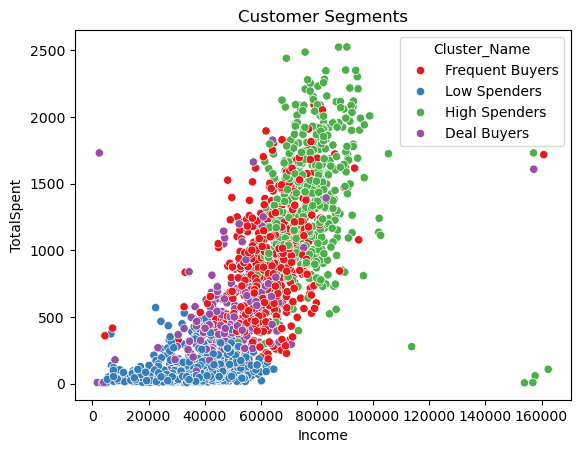

In [72]:

sns.scatterplot(data=df,x='Income',y='TotalSpent',hue='Cluster_Name',palette='Set1')
plt.title("Customer Segments")
plt.show()

Davies–Bouldin Index

In [73]:
from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(X_pca, labels)
print("Davies-Bouldin Index for K-Means:", db_score)

Davies-Bouldin Index for K-Means: 0.8408977457753052


In [74]:
from sklearn.metrics import calinski_harabasz_score

ch_score = calinski_harabasz_score(X_pca, labels)
print("Calinski-Harabasz Score for K-Means:", ch_score)

Calinski-Harabasz Score for K-Means: 2392.0861569123226


In [75]:
import joblib

joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")
joblib.dump(kmeans, "kmeans_model.pkl")

['kmeans_model.pkl']